# Chain comparison (fraction sweep)

Loads [`compare_chains.py`](compare_chains.py) helpers + a YAML config (same schema as the CLI). **0.2** is used only for `kind: random`; `kind: al` defaults to **0.3–0.7**.

Per-chain color is optional in YAML: `color: "red"`, `color: "#1f77b4"`, or `color: [31, 119, 180]` / `[0.12, 0.47, 0.71]`.

Edit `CONFIG_PATH` or the YAML file, then re-run.

In [9]:
%matplotlib inline

import importlib
import os
import sys
from pathlib import Path

import pandas as pd
import yaml

ROOT = Path.cwd().resolve()
for cand in (ROOT, ROOT.parent):
    if (cand / "compare_chains.py").is_file():
        ROOT = cand
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import compare_chains as _cc
_cc = importlib.reload(_cc)

expand_runs_dir = _cc.expand_runs_dir
format_frac = _cc.format_frac
load_chain_defs = _cc.load_chain_defs
make_chain_figure = _cc.make_chain_figure
series_for_chain = _cc.series_for_chain

CONFIG_PATH = ROOT / "configs" / "chain_compare_example.yaml"

In [10]:
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

runs_dir = expand_runs_dir(cfg.get("runs_dir", "~/ultralytics/runs/detect"))
metric = cfg.get("metric", "metrics/mAP50-95(B)")
title = cfg.get("title")

chain_defs = load_chain_defs(cfg)
series = []
for c in chain_defs:
    label = str(c["label"])
    color = c.get("color")
    xs, ys, names = series_for_chain(c, runs_dir, metric)
    series.append((label, xs, ys, color))
    for x, y, n in zip(xs, ys, names):
        if y is None:
            print(
                f"[warn] {label}: missing {runs_dir / n / 'results.csv'} (frac {format_frac(x)})"
            )

[warn] distance scratch v3: missing /home/setupishe/ultralytics/runs/detect/VOC_distance_0.2_s_scratch_v3/results.csv (frac 0.2)
[warn] distance scratch matre fast: missing /home/setupishe/ultralytics/runs/detect/VOC_distance_0.2_s_scratch_matrE_fast/results.csv (frac 0.2)


In [ ]:
all_fracs = sorted({x for _, xs, _, _ in series for x in xs})
rows = []
for frac in all_fracs:
    row = {"fraction": format_frac(frac)}
    for label, xs, ys, _ in series:
        if frac not in xs:
            row[label] = None
        else:
            j = xs.index(frac)
            row[label] = ys[j]
    rows.append(row)

df = pd.DataFrame(rows).set_index("fraction")
display(df)
print(f"metric: {metric}")

,random scratch,random scratch mat_everything,random scratch mat_everything_fast,distance scratch v3,distance scratch matre fast
fraction,,,,,
0.2,0.32810,0.3310,0.32666,NaN,NaN
0.3,0.39619,0.3904,0.39470,0.39967,0.39988
0.4,0.43783,NaN,0.43558,0.44946,0.44143
0.5,0.47270,NaN,0.47092,0.48022,0.47972
0.6,0.52425,NaN,0.52791,0.53878,0.53058
0.7,0.54981,NaN,0.54842,0.55703,0.54995


metric: metrics/mAP50-95(B)


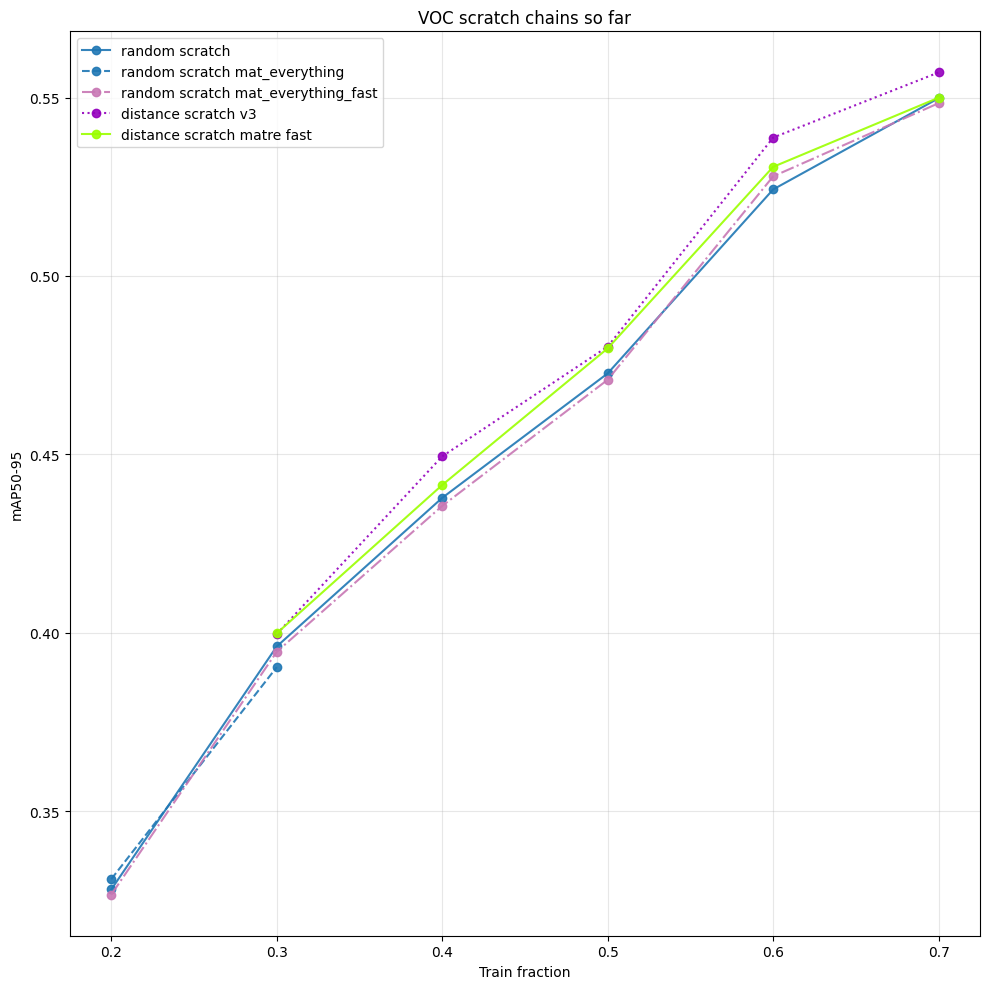

In [12]:
fig = make_chain_figure(series, metric, title)